# Preference learning
Paviel Mamchur (154978), Krzysztof Garsztka (155954)

### XGBoost

**Import modules**

In [28]:
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import plot_tree
import shap

**Load data**

In [29]:
def load_data(
    path: str, target_map: dict, criteria_nr: int
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Preprocesses the data for training a machine learning model.

    Args:
        path (str): The path to the CSV file containing the data.
        target_map (dict): A dictionary mapping target values to binary labels.
        criteria_nr (int): The number of criteria used for classification.

    Returns:
        tuple: A tuple containing the preprocessed data and the train-test split.
    """
    # Read the data from the CSV file
    data = pd.read_csv(path, header=None)

    # Apply the target mapping to convert target values to binary labels
    data[criteria_nr] = data[criteria_nr].apply(lambda x: target_map[int(x)])

    # Remove duplicate rows from the data
    data = data.drop_duplicates()

    # Split the data into input features and target variable
    data_input = data.iloc[:, :criteria_nr]
    data_target = data[criteria_nr]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        data_input, data_target, test_size=0.2, random_state=14
    )

    return (X_train, X_test, y_train, y_test)


# Load the data and preprocess it
path = "data/social_workers_decisions.csv"
target_map = {1: 0, 2: 0, 3: 0, 4: 1, 5: 1}
criteria_nr = 10
X_train, X_test, y_train, y_test = load_data(path, target_map, criteria_nr)

**XGBoost parameters**

In [30]:
params = {
    "max_depth": criteria_nr * 2,  # Maximum depth of a tree
    "eta": 0.1,  # Learning rate
    "nthread": 6,  # Number of parallel threads
    "seed": 42,  # Random seed
    "eval_metric": "rmse",  # Evaluation metric
    "monotone_constraints": "("
    + ",".join(["1"] * criteria_nr)
    + ")",  # Monotonic constraints for each criterion (1 = increasing, -1 = decreasing, 0 = no constraint)
    "n_estimators": 1,  # Number of boosting rounds, or trees
}

**Fitting the model**

In [31]:
model = xgb.XGBClassifier(**params)
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


**Metrics**

In [32]:
print("Training set")
print("=" * 20)
y_train_pred = model.predict(X_train)
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"F1 score: {f1_score(y_train, y_train_pred):.4f}")
print(f"AUC: {roc_auc_score(y_train, y_train_pred):.4f}")
print()
print("Testing set")
print("=" * 20)
y_test_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"F1 score: {f1_score(y_test, y_test_pred):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_test_pred):.4f}")

Training set
Accuracy: 0.6074
F1 score: 0.6364
AUC: 0.6069

Testing set
Accuracy: 0.3415
F1 score: 0.3415
AUC: 0.3588


**Visualization**

<Axes: >

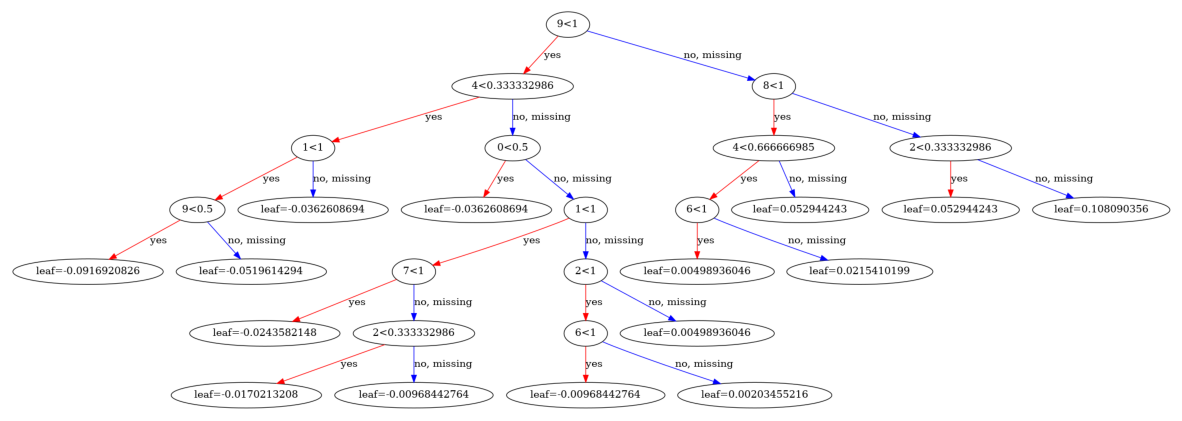

In [33]:
fig, ax = plt.subplots(figsize=(15, 15))

plot_tree(model, ax=ax, num_trees=0)

In [34]:
X_test[:10]

,0,1,2,3,4,5,6,7,8,9
50,0.0,0.0,0.000000,0.5,0.000000,0.0,1.0,1.0,0.0,0.0
153,0.5,0.5,0.000000,0.5,0.666667,0.0,0.5,0.5,0.5,0.0
223,1.0,0.5,0.666667,0.0,0.000000,0.0,0.0,0.5,1.0,0.0
189,1.0,1.0,0.333333,0.0,0.333333,1.0,1.0,1.0,1.0,1.0
5,0.5,0.5,0.666667,0.5,1.000000,1.0,0.5,0.5,0.5,0.0
172,1.0,1.0,1.000000,0.0,1.000000,1.0,1.0,1.0,1.0,0.5
26,0.0,0.5,0.333333,1.0,0.666667,1.0,0.5,0.0,0.0,0.5
16,0.5,0.0,0.333333,0.5,0.666667,0.0,0.5,0.5,1.0,0.0
88,0.5,1.0,1.000000,0.0,0.666667,1.0,0.5,0.0,0.5,0.5
204,0.0,0.5,0.333333,1.0,0.666667,1.0,0.5,0.0,0.0,0.5


In [35]:
changed = []
for i in range(30):
    for j in range(criteria_nr - 1):
        b_X_test = X_test.iloc[[i]].copy()
        b_X_test.at[b_X_test.index[0], j] = b_X_test.at[b_X_test.index[0], j] + 0.1
        b_y_pred = model.predict(b_X_test)
        if b_y_pred[0] != y_test_pred[i]:
            changed.append((i, j, 0.1))
            
        b_X_test.at[b_X_test.index[0], j] = b_X_test.at[b_X_test.index[0], j] - 0.2
        b_y_pred = model.predict(b_X_test)
        if b_y_pred[0] != y_test_pred[i]:
            changed.append((i, j, -0.1))

print("Changed predictions:")
for i, j, change in changed:    
    print(f"Sample {i}, Criterion {j}, Change: {change}")

Changed predictions:
Sample 8, Criterion 0, Change: -0.1
Sample 8, Criterion 1, Change: -0.1
Sample 20, Criterion 0, Change: -0.1
Sample 20, Criterion 2, Change: -0.1
Sample 20, Criterion 4, Change: -0.1
Sample 20, Criterion 7, Change: -0.1
Sample 27, Criterion 0, Change: -0.1
Sample 27, Criterion 1, Change: -0.1
Sample 28, Criterion 1, Change: -0.1


In [39]:
b_X_test = X_test.iloc[[27]].copy()

b_X_test.at[b_X_test.index[0], 1] = b_X_test.at[b_X_test.index[0], 1] - 0.1

print(b_X_test)
b_y_pred = model.predict(b_X_test)
print(f"Original Prediction: {y_test_pred[27]}")
print(f"New Prediction: {b_y_pred[0]}")

       0    1         2    3    4    5    6    7    8    9
408  0.5  0.9  0.666667  0.5  1.0  0.0  1.0  0.5  1.0  0.0
Original Prediction: 1
New Prediction: 0


**SHAP**

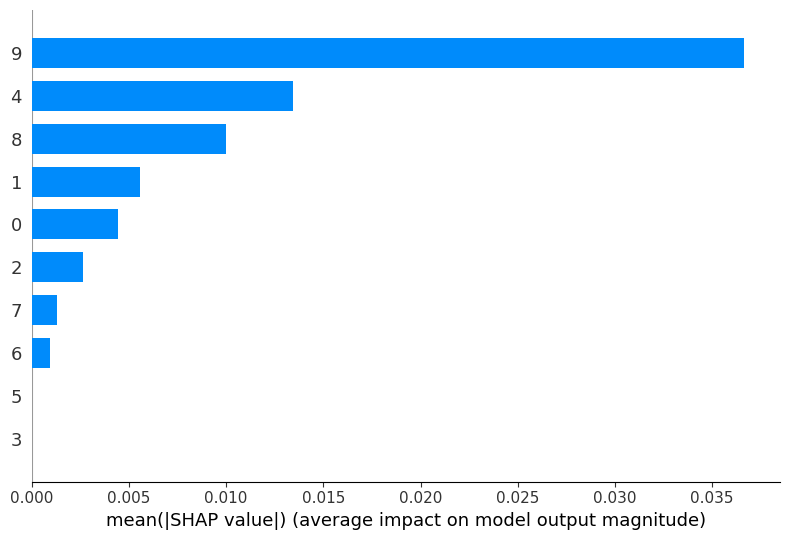

In [10]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

**Partial dependence**

In [40]:
def partial_dependency(
    booster: xgb.Booster, X: np.ndarray, y: pd.Series, f_id: int
) -> Tuple[np.ndarray, np.ndarray]:
    """Calculate the partial dependency of a feature on the predicted outcome.
    Args:
        booster (xgb.Booster): The trained XGBoost model.
        X (np.ndarray): The input feature matrix.
        y (pd.Series): The target variable.
        f_id (int): The index of the feature for which the partial dependency is calculated.

    Returns:
        Tuple[np.ndarray, np.ndarray]: A tuple containing two numpy arrays:
        - grid: The values of the feature used for calculation.
        - y_pred: The predicted outcomes corresponding to each value in the grid.
    """
    grid = np.linspace(0, 1, 50)
    y_pred = np.zeros(len(grid))
    for i, val in enumerate(grid):
        X_temp = X.copy()
        X_temp[:, f_id] = val
        data = xgb.DMatrix(pd.DataFrame(X_temp))
        y_pred[i] = np.average(booster.predict(data))
    return grid, y_pred

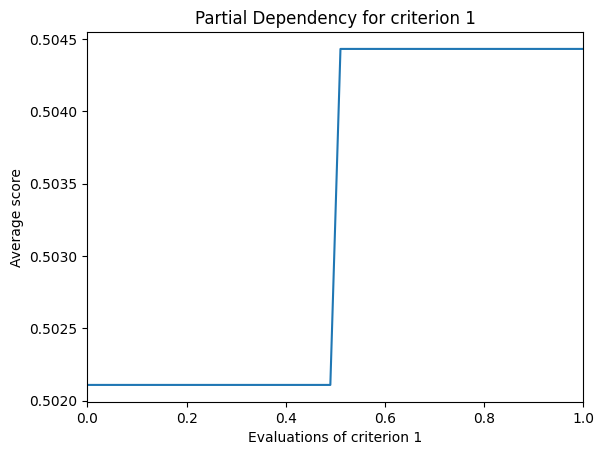

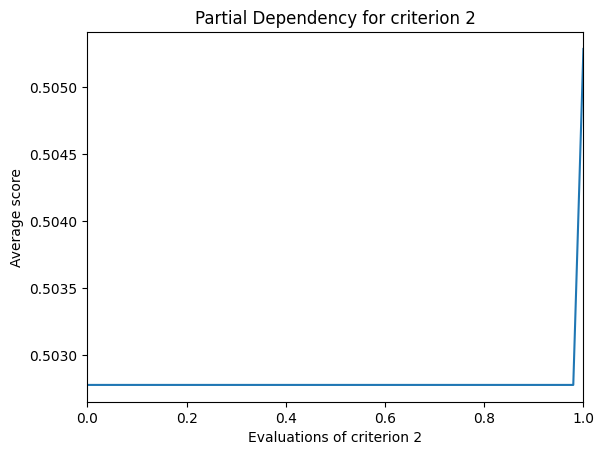

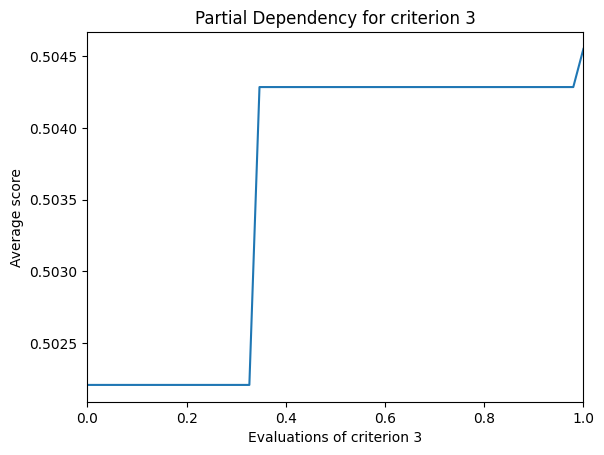

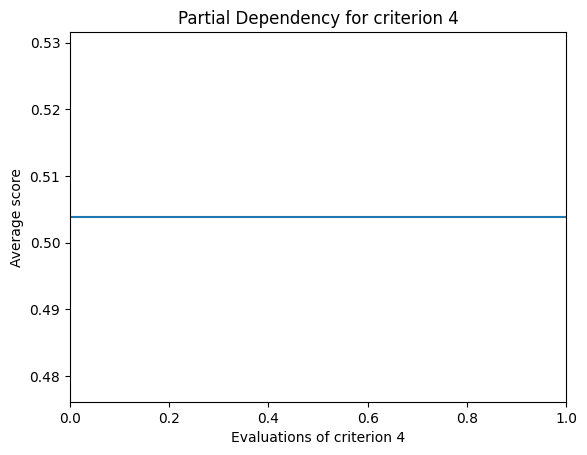

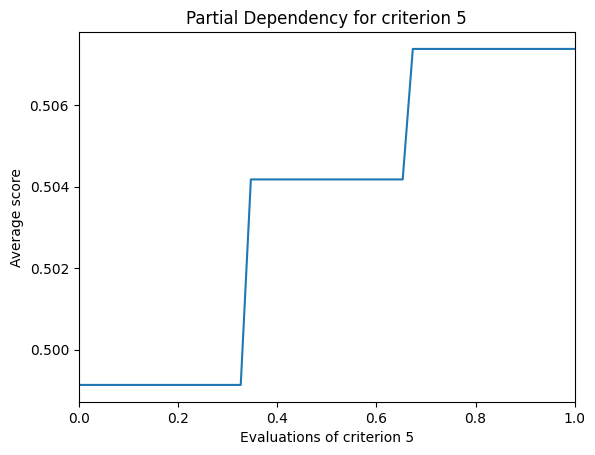

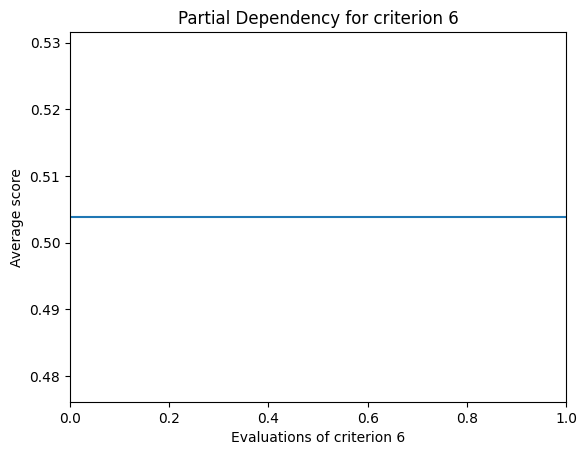

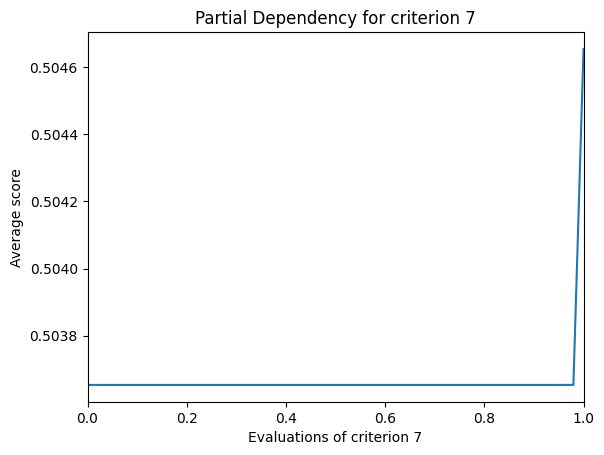

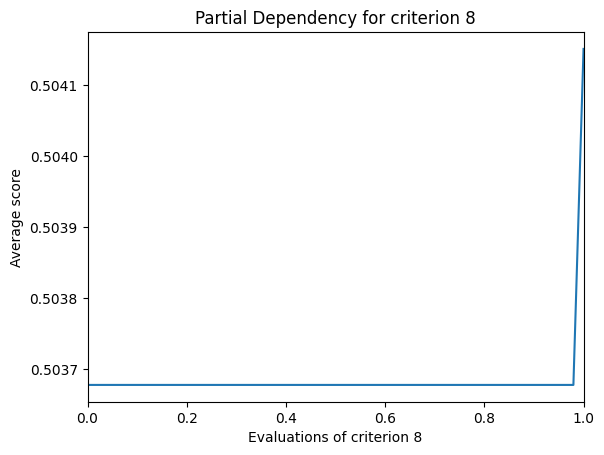

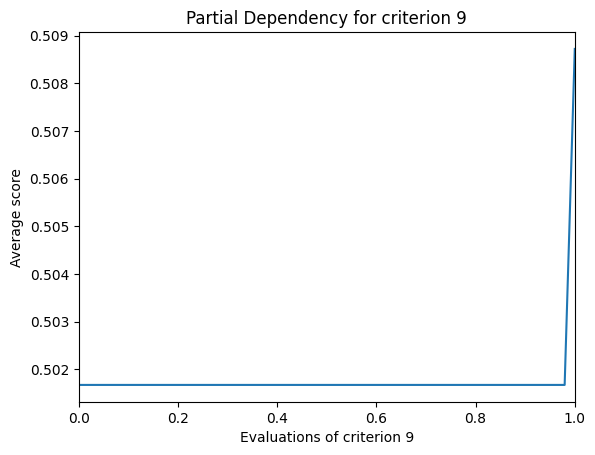

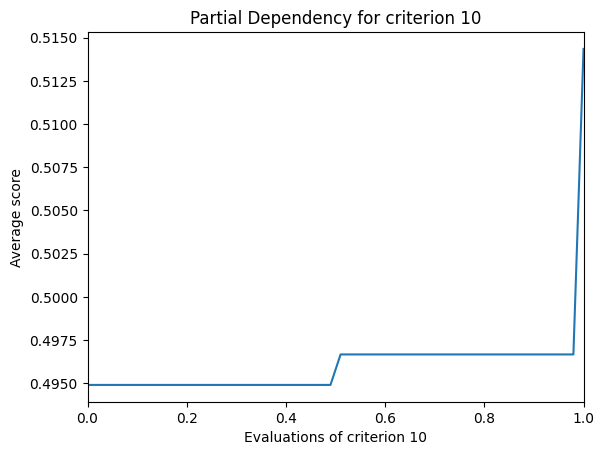

In [41]:
booster = model.get_booster()
grid = np.linspace(0, 1, 50)

for c in range(criteria_nr):
    grid, y_pred = partial_dependency(booster, X_train.values, y_train, c)
    fig, ax = plt.subplots()
    ax.plot(grid, y_pred)
    ax.set_xlim(0, 1)
    ax.set_title(f"Partial Dependency for criterion {c+1}")
    ax.set_xlabel(f"Evaluations of criterion {c+1}")
    ax.set_ylabel("Average score")

### UTADIS

**Import modules**

In [43]:
import torch
from utils import *
from uta import Uta
from norm_layer import NormLayer

**Load data**

In [44]:
path = "data/social_workers_decisions.csv"
data = pd.read_csv(path, header=None)
target_map = {1: 0, 2: 0, 3: 0, 4: 1, 5: 1}
num_criteria = criteria_nr
data_input = data.iloc[:, :num_criteria]
data_target = data[num_criteria].apply(lambda x: target_map[x])

data_input = data_input.values.reshape(-1, 1, num_criteria)

X_train, X_test, y_train, y_test = train_test_split(
    data_input, data_target.values, test_size=0.2, random_state=1234
)

train_dataloader = CreateDataLoader(X_train, y_train)
test_dataloader = CreateDataLoader(X_test, y_test)

**Train model**

In [45]:
uta = Uta(num_criteria, 30)
PATH = "uta.pt2"

model = NormLayer(uta, num_criteria)
(
    best_acc,
    best_auc,
    best_f1,
    stats_train,
    stats_test,
) = Train(model, train_dataloader, test_dataloader, PATH,epoch_nr=200,lr =0.0001,slope_decrease=True)

100%|██████████| 200/200 [00:01<00:00, 110.34it/s]


**Metrics**

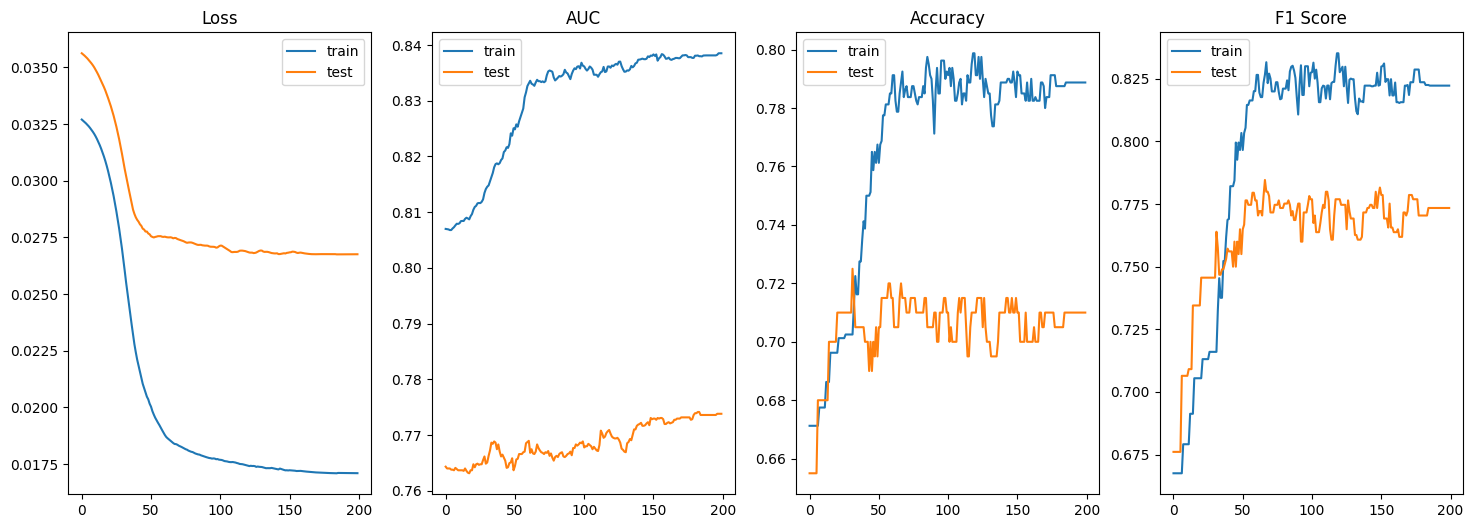

In [46]:
fig = plt.figure(figsize=(18,6))

ax = fig.add_subplot(141)
ax.plot(stats_train.losses,label='train')
ax.plot(stats_test.losses,label='test')
ax.set_title('Loss')
ax.legend()

ax = fig.add_subplot(142)
ax.plot(stats_train.auc_scores,label='train')
ax.plot(stats_test.auc_scores,label='test')
ax.set_title('AUC')
ax.legend()

ax = fig.add_subplot(143)
ax.plot(stats_train.acc_scores,label='train')
ax.plot(stats_test.acc_scores,label='test')
ax.set_title('Accuracy')
ax.legend()

ax = fig.add_subplot(144)
ax.plot(stats_train.f1_scores,label='train')
ax.plot(stats_test.f1_scores,label='test')
ax.set_title('F1 Score')
ax.legend()

**Marginal value functions**

In [47]:
checkpoint = torch.load(PATH)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

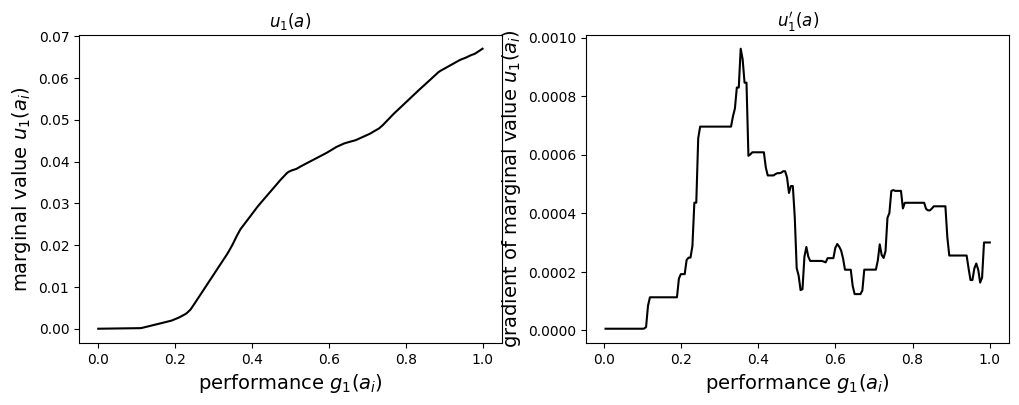

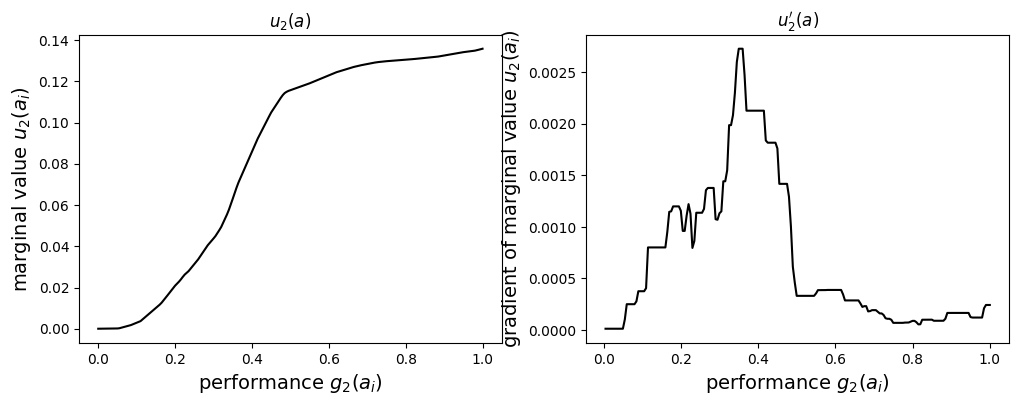

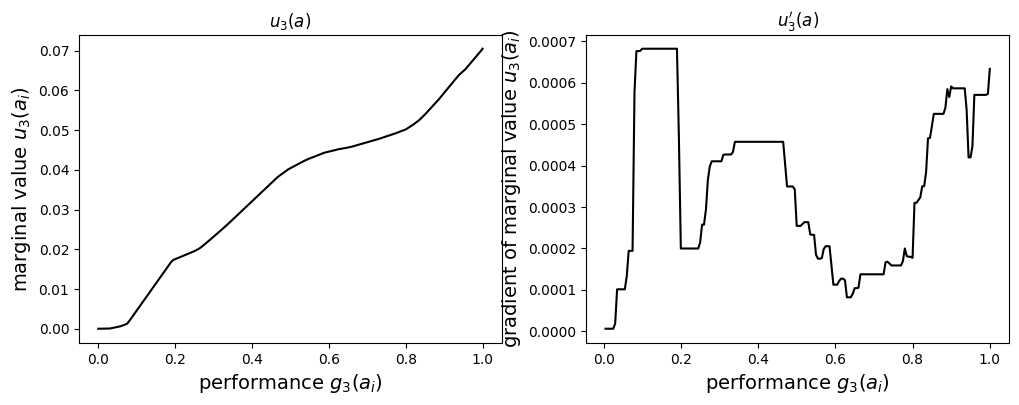

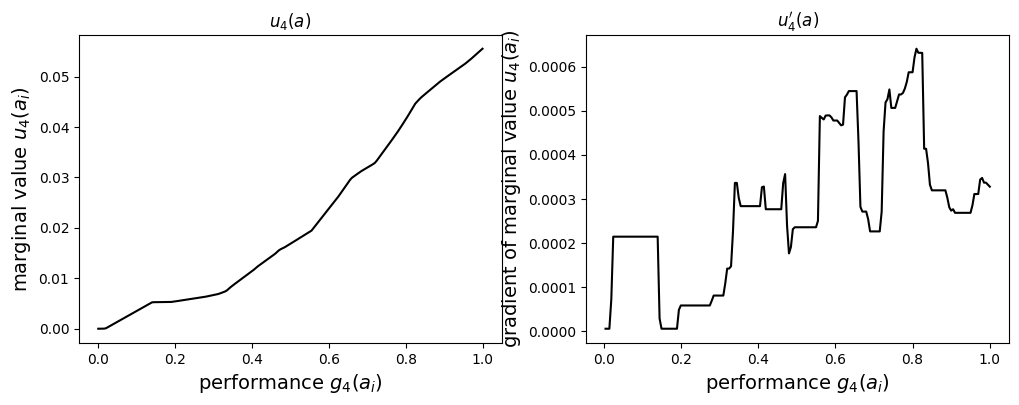

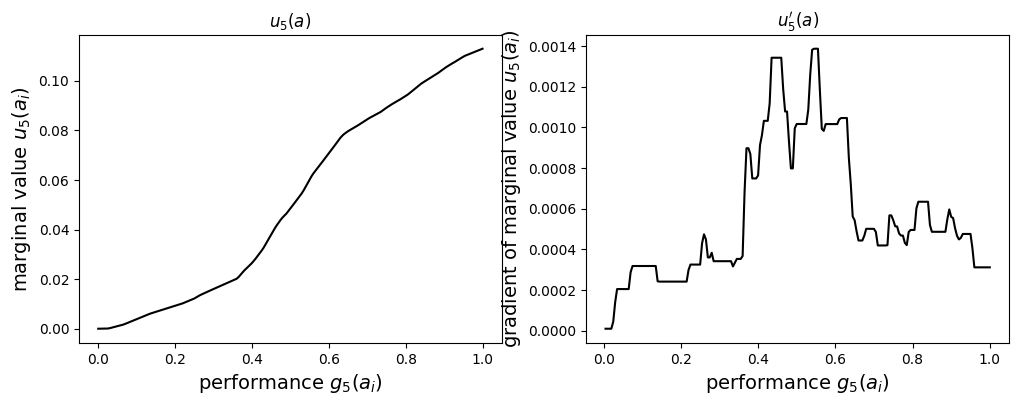

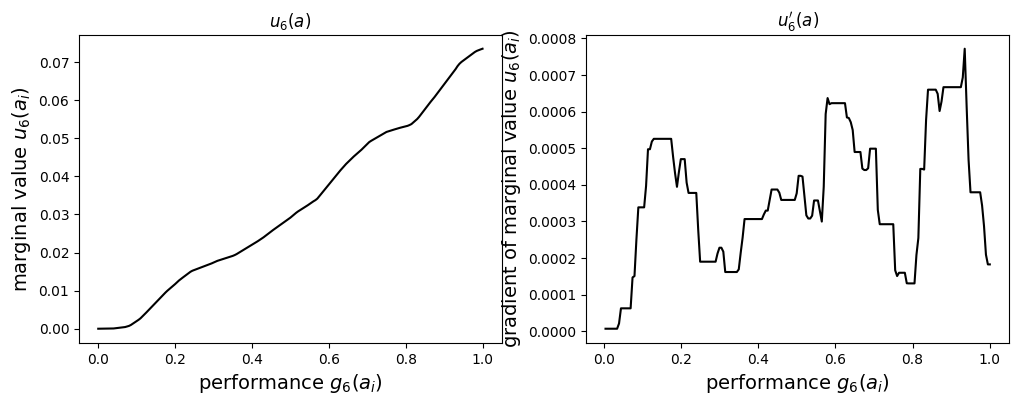

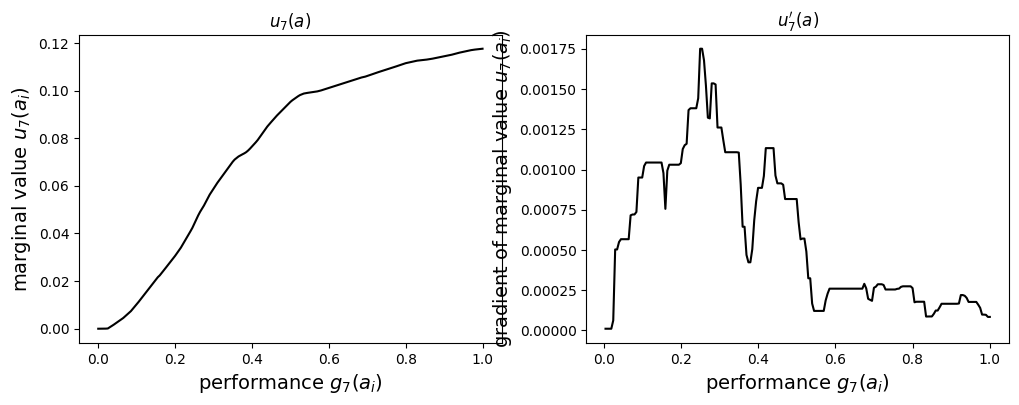

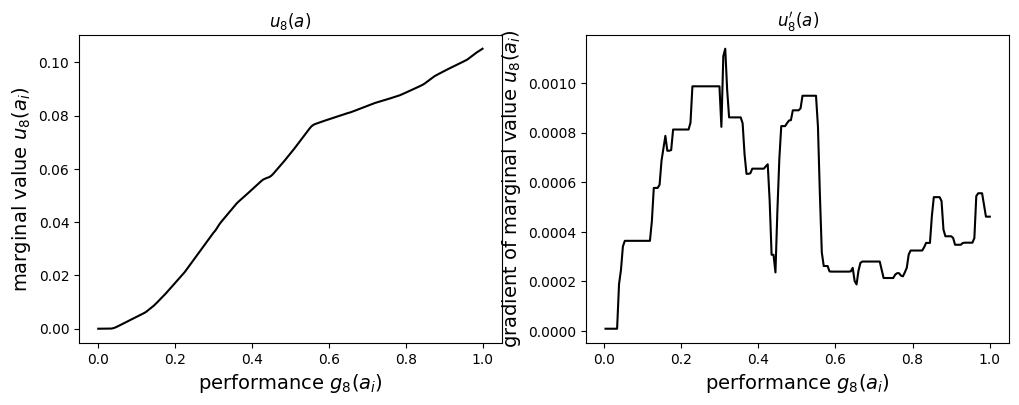

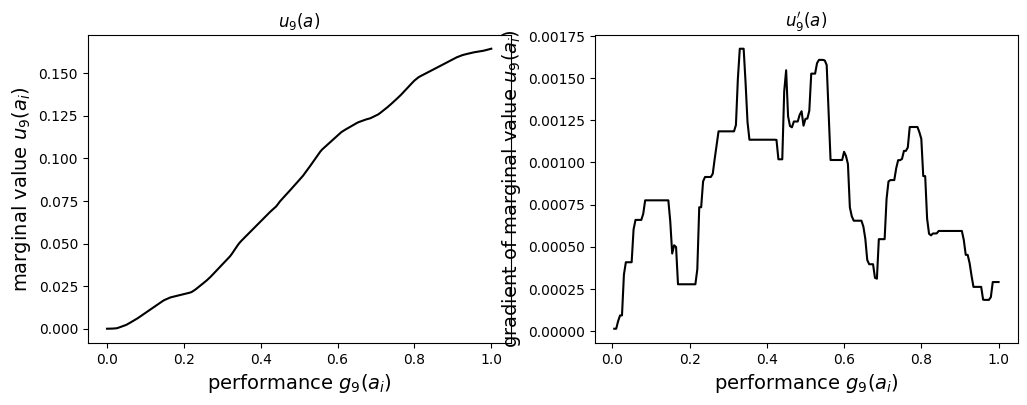

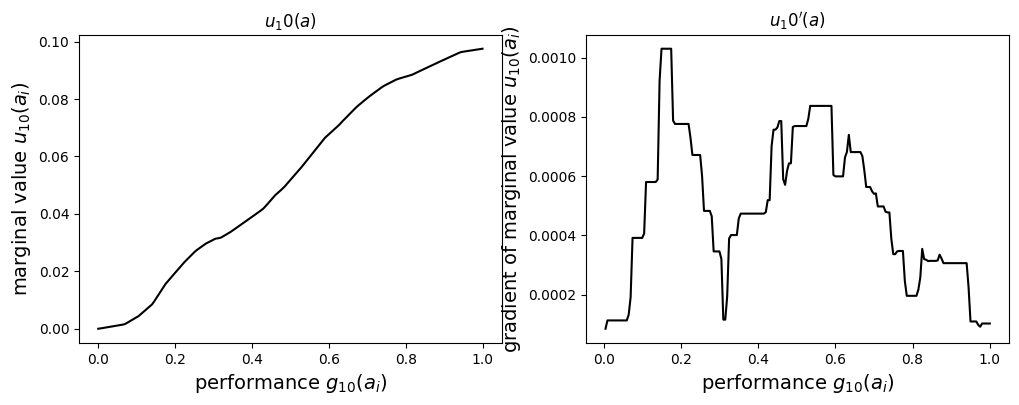

In [48]:
hook = Hook(model.method_instance.monotonic_layer, append_output)
xs = []
with torch.no_grad():
    for i in range(201):
        val = i / 200.0
        x = get_simple_input(val,num_criteria)
        xs.append(val)
        model(x)

outs = np.array(torch.stack(hook.stats)[:, 0].detach().cpu())
# We take every third value becouse the rest are from the normalization layer: velues for 0 and 1
outs = outs[::3] - outs[::3][0]
# Normalize the outputs to get proper weights of the criteria
outs = outs / outs[-1].sum()

for i in range(num_criteria):
    criterion_number = i + 1
    fig = plt.figure(figsize=(12,4))  
    ax = fig.add_subplot(121)
    ax.set_title(f'$u_{criterion_number}(a)$')
    ax.plot(xs, outs[:, i], color="black")
    ax.set_ylabel(f"marginal value $u_{{{criterion_number}}}(a_i)$", fontsize=14)
    ax.set_xlabel(f"performance $g_{{{criterion_number}}}(a_i)$", fontsize=14)

    ax = fig.add_subplot(1,2,2)
    ax.set_title(f"$u_{criterion_number}'(a)$")
    ax.plot(xs[1:], outs[1:, i]-outs[:-1, i], color="black")
    ax.set_ylabel(f"gradient of marginal value $u_{{{criterion_number}}}(a_i)$", fontsize=14)
    ax.set_xlabel(f"performance $g_{{{criterion_number}}}(a_i)$", fontsize=14)
    plt.show()

In [49]:
y_pred = np.array([model(torch.tensor(x, dtype=torch.float32)).detach().numpy() for x in X_test]).squeeze()
y_pred = (y_pred > 0.0).astype(int)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.7100


**Decision boundary analysis using guided gradients**

In [106]:
def find_minimal_change(model, variant_tensor, feature_idx, target_threshold=0.0):
    model.eval()
    original_val = variant_tensor[0, 0, feature_idx].item()
    current_variant = variant_tensor.clone()
    
    with torch.no_grad():
        old_prob = model(current_variant).item()
    
    steps = np.linspace(0.0, 1.0, 100)
    for val in steps:
        current_variant[0, 0, feature_idx] = val
        with torch.no_grad():
            prob = model(current_variant).item()
        
        if (old_prob > target_threshold and prob <= target_threshold) or \
           (old_prob <= target_threshold and prob > target_threshold):
            change = val - original_val
            return val, change, prob, old_prob
            
    return None, None, None, None
cnt = 0

for i in range(30):
    for j in range(num_criteria):
        var_input_tensor = torch.Tensor(X_train[i]).unsqueeze(0)
        new_val, diff, new_prob, old_prob = find_minimal_change(model, var_input_tensor, j)
        if diff is not None:
            cnt += 1
            print(f"Zmiana wariantu {i} kryterium {j+1}: {diff:.4f} (Nowa wartość: {new_val:.4f}, Stare pr: {old_prob:.4f}, Nowe pr: {new_prob:.4f})")
        if cnt > 20:
            break
    if cnt > 20:
        break

Zmiana wariantu 0 kryterium 7: -0.5000 (Nowa wartość: 0.0000, Stare pr: 0.0900, Nowe pr: -0.0053)
Zmiana wariantu 0 kryterium 8: -1.0000 (Nowa wartość: 0.0000, Stare pr: 0.0900, Nowe pr: -0.0151)
Zmiana wariantu 2 kryterium 2: 0.2929 (Nowa wartość: 0.2929, Stare pr: -0.0404, Nowe pr: 0.0018)
Zmiana wariantu 2 kryterium 3: 0.6364 (Nowa wartość: 0.9697, Stare pr: -0.0404, Nowe pr: 0.0006)
Zmiana wariantu 2 kryterium 4: 0.7980 (Nowa wartość: 0.7980, Stare pr: -0.0404, Nowe pr: 0.0008)
Zmiana wariantu 2 kryterium 6: 0.6263 (Nowa wartość: 0.6263, Stare pr: -0.0404, Nowe pr: 0.0007)
Zmiana wariantu 2 kryterium 8: 0.3232 (Nowa wartość: 0.3232, Stare pr: -0.0404, Nowe pr: 0.0003)
Zmiana wariantu 2 kryterium 9: 0.2172 (Nowa wartość: 0.7172, Stare pr: -0.0404, Nowe pr: 0.0002)
Zmiana wariantu 3 kryterium 7: -1.0000 (Nowa wartość: 0.0000, Stare pr: 0.1021, Nowe pr: -0.0155)
Zmiana wariantu 4 kryterium 7: -1.0000 (Nowa wartość: 0.0000, Stare pr: 0.1173, Nowe pr: -0.0003)
Zmiana wariantu 5 kryteriu

In [110]:
def get_guided_gradients(model, input_tensor, target_class=1):
    input_tensor = input_tensor.clone().detach().requires_grad_(True)
    
    output = model(input_tensor)
    
    model.zero_grad()
    if output.shape[-1] > 1:
        target = output[0][target_class]
    else:
        target = output
        
    target.backward()
    
    gradients = input_tensor.grad.data
    
    return (gradients, target.item())

selected_variants = range(7)
epsilon = 0.01
for i in selected_variants:
    min_change = float('inf')
    best_criterion = -1
    old_out = -1
    new_out = -1
    final_change = 0
    
    var_input_orig = X_train[i].copy()
    var_input_tensor = torch.Tensor(var_input_orig).unsqueeze(0)
    
    grads, target_val = get_guided_gradients(model, var_input_tensor)
    current_class = int(target_val > 0.0)
    
    print("="*30)
    print(f"ANALIZA WARIANTU {i} (Klasa: {current_class}, Wynik: {target_val:.4f})")
    
    for j in range(num_criteria):
        g = grads[0, 0, j].item()
        
        if abs(g) < 1e-5:
            continue
            
        analytical_change = -target_val / g
        
        direction = 1 if analytical_change > 0 else -1
        suggested_change = analytical_change + (direction * epsilon)
        
        new_val = var_input_orig[0, j] + suggested_change
        
        if 0.0 <= new_val <= 1.0:
            var_test = var_input_orig.copy()
            var_test[0, j] = new_val
            test_tensor = torch.Tensor(var_test).unsqueeze(0)
            
            with torch.no_grad():
                test_output = model(test_tensor).item()
                test_class = int(test_output > 0.0)
            
            if test_class != current_class:
                if abs(suggested_change) < min_change:
                    min_change = abs(suggested_change)
                    final_change = suggested_change
                    best_criterion = j
                    old_out = current_class
                    new_out = test_class

    if best_criterion != -1:
        print(f"Minimalna zmiana na Kryterium {best_criterion + 1}")
        print(f"Wartość zmiany: {final_change:.4f}")
        print(f"Nowa wartość cechy: {var_input_orig[0, best_criterion] + final_change:.4f}")
        print(f"Zmiana klasy: {old_out} -> {new_out}")
        print(X_train[i])
    else:
        print("BRAK MOŻLIWOŚCI ZMIANY KLASY poprzez modyfikację tylko jednego kryterium.")

ANALIZA WARIANTU 0 (Klasa: 1, Wynik: 0.0900)
Minimalna zmiana na Kryterium 8
Wartość zmiany: -0.9851
Nowa wartość cechy: 0.0149
Zmiana klasy: 1 -> 0
[[1.       0.       0.333333 0.       0.666667 1.       0.5      1.
  0.5      0.5     ]]
ANALIZA WARIANTU 1 (Klasa: 1, Wynik: 0.2600)
BRAK MOŻLIWOŚCI ZMIANY KLASY poprzez modyfikację tylko jednego kryterium.
ANALIZA WARIANTU 2 (Klasa: 0, Wynik: -0.0404)
BRAK MOŻLIWOŚCI ZMIANY KLASY poprzez modyfikację tylko jednego kryterium.
ANALIZA WARIANTU 3 (Klasa: 1, Wynik: 0.1021)
BRAK MOŻLIWOŚCI ZMIANY KLASY poprzez modyfikację tylko jednego kryterium.
ANALIZA WARIANTU 4 (Klasa: 1, Wynik: 0.1173)
BRAK MOŻLIWOŚCI ZMIANY KLASY poprzez modyfikację tylko jednego kryterium.
ANALIZA WARIANTU 5 (Klasa: 1, Wynik: 0.0560)
Minimalna zmiana na Kryterium 9
Wartość zmiany: -0.2321
Nowa wartość cechy: 0.2679
Zmiana klasy: 1 -> 0
[[0.       1.       0.666667 0.       1.       1.       0.       0.
  0.5      1.      ]]
ANALIZA WARIANTU 6 (Klasa: 0, Wynik: -0.0342)

### Neural Network (Blackbox)

**Import modules**

In [113]:
import torch.nn as nn

**Architecture**

In [114]:
class MCDANN(torch.nn.Module):
    def __init__(self, num_criteria):
        super(MCDANN, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(num_criteria, 128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(128, 64),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(64, 32),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

**Training**

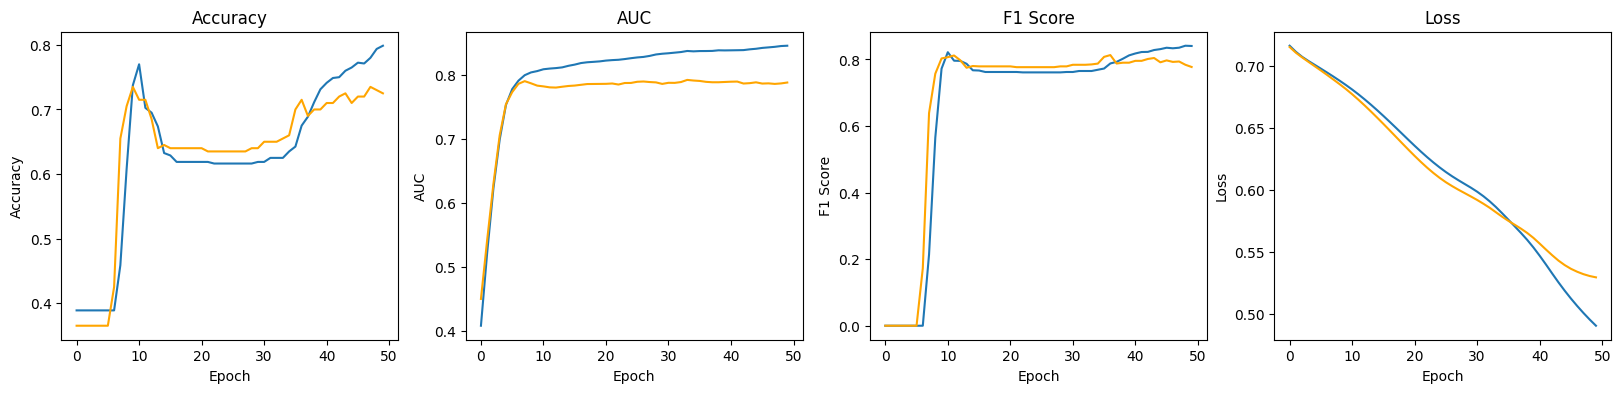

In [115]:
model = MCDANN(num_criteria)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

epochs = 50

total_train_loss = np.array([])
total_train_acc = np.array([])
total_train_auc = np.array([])
total_train_f1 = np.array([])

total_test_loss = np.array([])
total_test_acc = np.array([])
total_test_auc = np.array([])
total_test_f1 = np.array([])

for epoch in range(epochs):
    train_loss = np.array([])
    train_acc = np.array([])
    train_auc = np.array([])
    train_f1 = np.array([])

    test_loss = np.array([])
    test_acc = np.array([])
    test_auc = np.array([])
    test_f1 = np.array([])

    for _, data in enumerate(train_dataloader, 0):
        inputs, targets = data
        model.train()
        optimizer.zero_grad()
        outputs = model(inputs).view(-1)

        y_true = targets.cpu().numpy().flatten()
        y_pred_labels = (outputs > 0.5).cpu().numpy().flatten()
        y_pred_probs = outputs.detach().cpu().numpy().flatten()

        loss = criterion(outputs, targets.float())

        train_loss = np.append(train_loss, [loss.item()])
        train_acc = np.append(train_acc, [accuracy_score(y_true, y_pred_labels)])
        train_auc = np.append(train_auc, [roc_auc_score(y_true, y_pred_probs)])
        train_f1 = np.append(train_f1, [f1_score(y_true, y_pred_labels)])

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    for _, data in enumerate(test_dataloader, 0):
        inputs, targets = data
        model.eval()
        with torch.no_grad():
            outputs = model(inputs).view(-1)
        
        y_true = targets.cpu().numpy().flatten()
        y_pred_labels = (outputs > 0.5).cpu().numpy().flatten()
        y_pred_probs = outputs.detach().cpu().numpy().flatten()

        loss = criterion(outputs, targets.float())

        test_loss = np.append(test_loss, [loss.item()])
        test_acc = np.append(test_acc, [accuracy_score(y_true, y_pred_labels)])
        test_auc = np.append(test_auc, [roc_auc_score(y_true, y_pred_probs)])
        test_f1 = np.append(test_f1, [f1_score(y_true, y_pred_labels)])

    total_train_loss = np.append(total_train_loss, [train_loss.mean()])
    total_train_acc = np.append(total_train_acc, [train_acc.mean()])
    total_train_auc = np.append(total_train_auc, [train_auc.mean()])
    total_train_f1 = np.append(total_train_f1, [train_f1.mean()])

    total_test_loss = np.append(total_test_loss, [test_loss.mean()])
    total_test_acc = np.append(total_test_acc, [test_acc.mean()])
    total_test_auc = np.append(total_test_auc, [test_auc.mean()])
    total_test_f1 = np.append(total_test_f1, [test_f1.mean()])

plt.figure(figsize=(20, 4))
plt.tight_layout()
plt.subplot(1, 4, 1)
plt.plot(total_train_acc, label='Train Accuracy')
plt.plot(total_test_acc, label='Test Accuracy', color='orange')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 4, 2)
plt.plot(total_train_auc, label='Train AUC')
plt.plot(total_test_auc, label='Test AUC', color='orange')
plt.title('AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')

plt.subplot(1, 4, 3)
plt.plot(total_train_f1, label='Train F1 Score')
plt.plot(total_test_f1, label='Test F1 Score', color='orange')
plt.title('F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')

plt.subplot(1, 4, 4)
plt.plot(total_train_loss, label='Train Loss')
plt.plot(total_test_loss, label='Test Loss', color='orange')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

    

In [116]:
for i in range(3):
    var_input = X_test[i]
    var_input_tensor = torch.Tensor(var_input).unsqueeze(0)
    grads, target = get_guided_gradients(model, var_input_tensor)
    
    target = int(target > 0)

    print("="*20)
    print(f"Variant {i} Influence (Gradients):")
    print(grads)
    print(f"Variant {i} Target Value:")
    print(f"Predicted: {target}")
    print(f"Actual: {y_test[i]}")

Variant 0 Influence (Gradients):
tensor([[[0.0439, 0.2010, 0.4147, 0.0090, 0.1165, 0.1228, 0.1468, 0.0046,
          0.0547, 0.0669]]])
Variant 0 Target Value:
Predicted: 1
Actual: 1
Variant 1 Influence (Gradients):
tensor([[[ 0.0414,  0.0502,  0.1347, -0.0193,  0.0850,  0.0244,  0.0773,
           0.0136,  0.0198,  0.0204]]])
Variant 1 Target Value:
Predicted: 1
Actual: 1
Variant 2 Influence (Gradients):
tensor([[[ 0.1200,  0.1630,  0.4788, -0.1932,  0.2488,  0.0124,  0.2982,
           0.0334,  0.1089,  0.0923]]])
Variant 2 Target Value:
Predicted: 1
Actual: 1


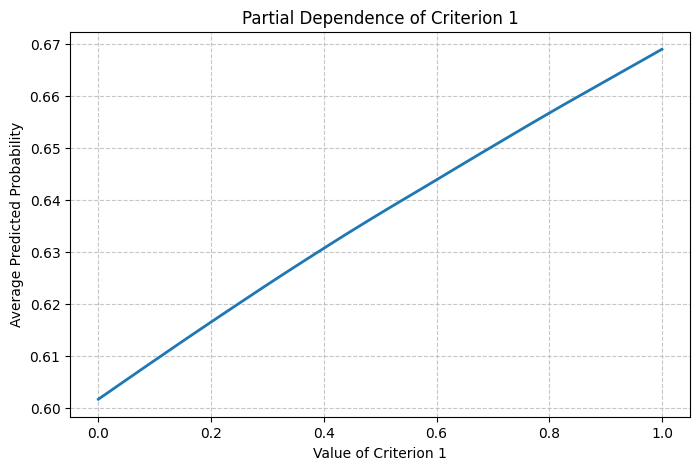

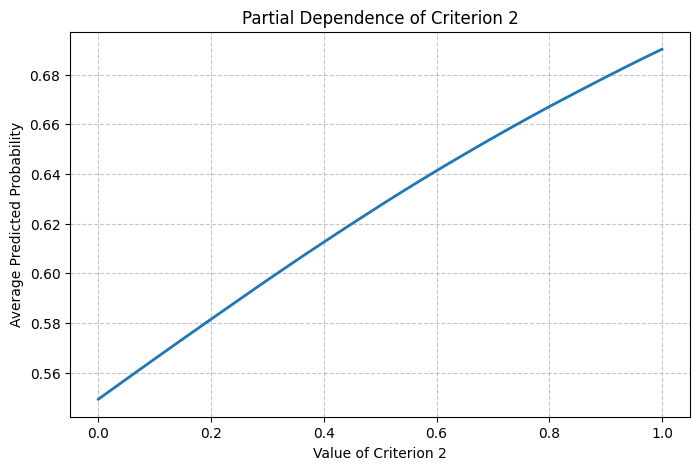

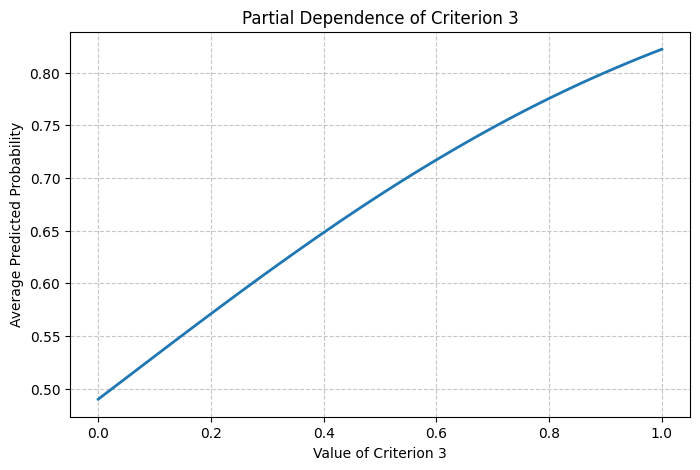

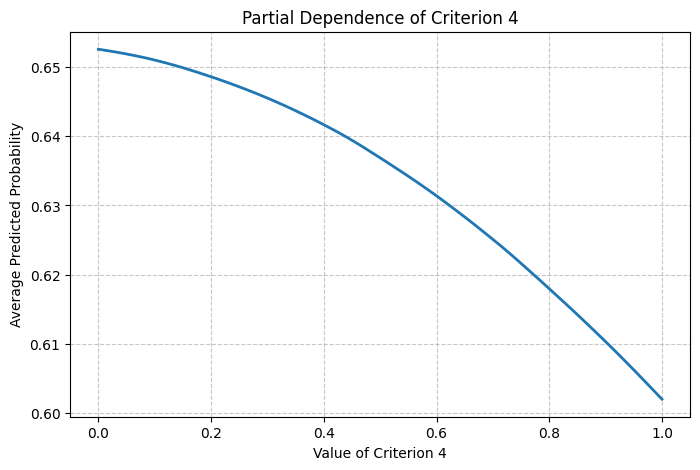

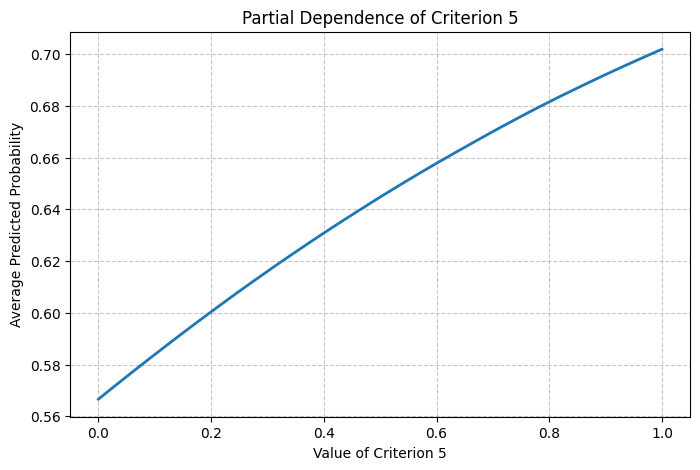

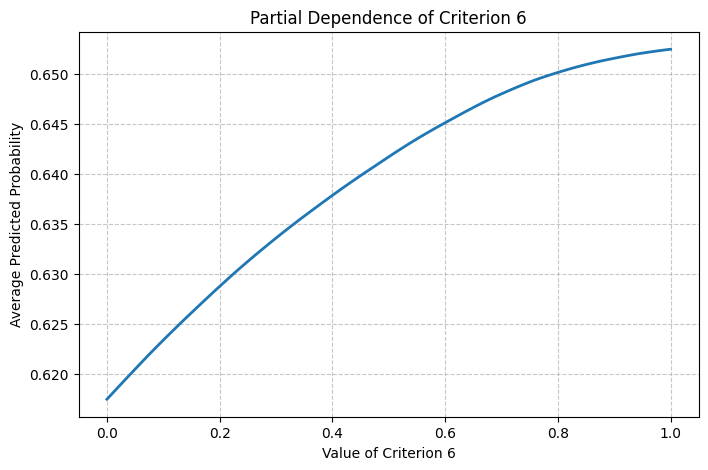

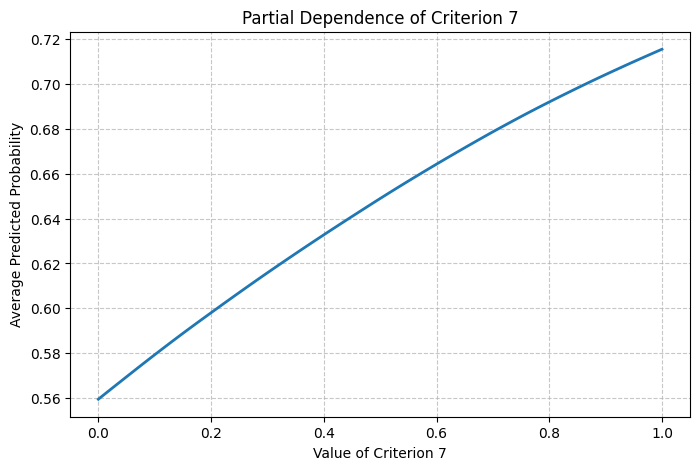

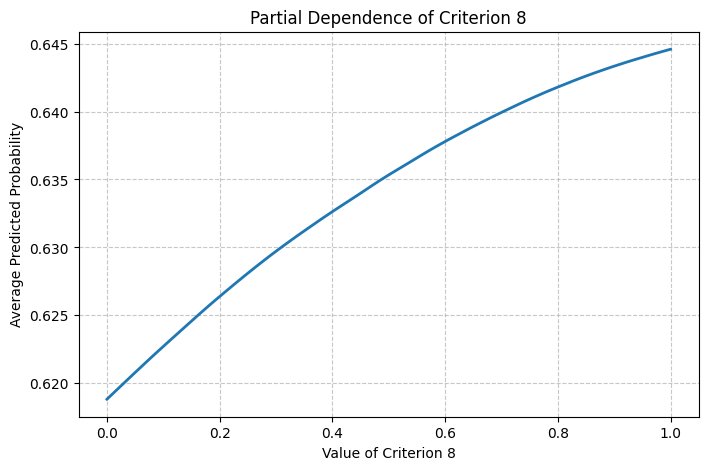

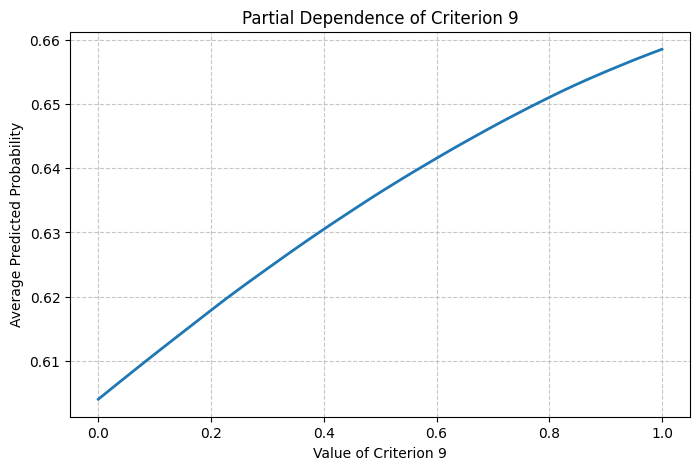

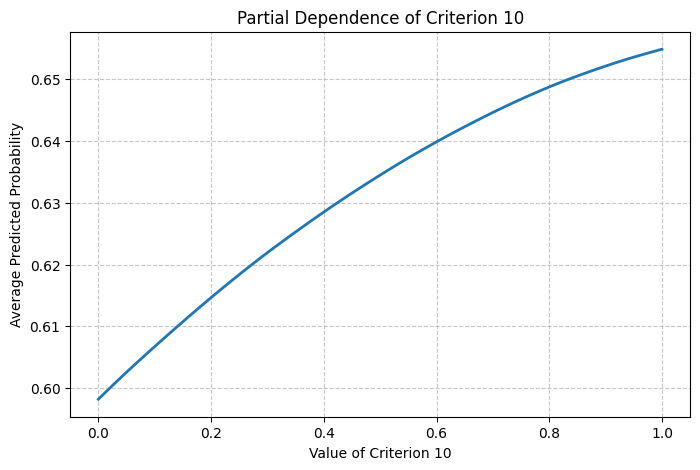

In [118]:
def plot_pdp(model, X_train, feature_idx, feature_name):
    if not torch.is_tensor(X_train):
        X_tensor = torch.tensor(X_train.values if hasattr(X_train, 'values') else X_train).float()
    else:
        X_tensor = X_train.float()

    if len(X_tensor.shape) == 2:
        X_tensor = X_tensor.unsqueeze(1)

    sweep = torch.linspace(0, 1, 100)
    pdp_values = []

    model.eval()
    with torch.no_grad():
        for val in sweep:
            temp_X = X_tensor.clone()
            
            if len(temp_X.shape) == 3:
                temp_X[:, 0, feature_idx] = val
            else:
                temp_X[:, feature_idx] = val
            
            preds = model(temp_X)
            pdp_values.append(preds.mean().item())

    plt.figure(figsize=(8, 5))
    plt.plot(sweep.numpy(), pdp_values, linewidth=2)
    plt.title(f"Partial Dependence of {feature_name}")
    plt.xlabel(f"Value of {feature_name}")
    plt.ylabel("Average Predicted Probability")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

for i in range(num_criteria):
    plot_pdp(model, X_train, i, f"Criterion {i+1}")

In [119]:
def find_minimal_change(model, variant_tensor, feature_idx, target_threshold=0.5):
    model.eval()
    original_val = variant_tensor[0, 0, feature_idx].item()
    current_variant = variant_tensor.clone()
    
    with torch.no_grad():
        old_prob = model(current_variant).item()
    
    steps = np.linspace(0.0, 1.0, 100)
    for val in steps:
        current_variant[0, 0, feature_idx] = val
        with torch.no_grad():
            prob = model(current_variant).item()
        
        if (old_prob > target_threshold and prob <= target_threshold) or \
           (old_prob <= target_threshold and prob > target_threshold):
            change = val - original_val
            return val, change, prob, old_prob
            
    return None, None, None, None
cnt = 0

for i in range(30):
    for j in range(num_criteria):
        var_input_tensor = torch.Tensor(X_train[i]).unsqueeze(0)
        new_val, diff, new_prob, old_prob = find_minimal_change(model, var_input_tensor, j)
        if diff is not None:
            cnt += 1
            print(f"Zmiana wariantu {i} kryterium {j+1}: {diff:.4f} (Nowa wartość: {new_val:.4f}, Stare pr: {old_prob:.4f}, Nowe pr: {new_prob:.4f})")
        if cnt > 20:
            break
    if cnt > 20:
        break

Zmiana wariantu 2 kryterium 3: -0.3333 (Nowa wartość: 0.0000, Stare pr: 0.6043, Nowe pr: 0.4289)
Zmiana wariantu 2 kryterium 5: -1.0000 (Nowa wartość: 0.0000, Stare pr: 0.6043, Nowe pr: 0.4492)
Zmiana wariantu 2 kryterium 10: -1.0000 (Nowa wartość: 0.0000, Stare pr: 0.6043, Nowe pr: 0.4990)
Zmiana wariantu 6 kryterium 2: -0.5000 (Nowa wartość: 0.0000, Stare pr: 0.5541, Nowe pr: 0.4290)
Zmiana wariantu 6 kryterium 3: -0.3333 (Nowa wartość: 0.0000, Stare pr: 0.5541, Nowe pr: 0.4143)
Zmiana wariantu 6 kryterium 5: -0.3333 (Nowa wartość: 0.0000, Stare pr: 0.5541, Nowe pr: 0.4873)
Zmiana wariantu 6 kryterium 7: -0.5000 (Nowa wartość: 0.0000, Stare pr: 0.5541, Nowe pr: 0.4863)
Zmiana wariantu 7 kryterium 2: -1.0000 (Nowa wartość: 0.0000, Stare pr: 0.7371, Nowe pr: 0.4688)
Zmiana wariantu 11 kryterium 2: -1.0000 (Nowa wartość: 0.0000, Stare pr: 0.7161, Nowe pr: 0.4836)
Zmiana wariantu 12 kryterium 1: 0.2626 (Nowa wartość: 0.2626, Stare pr: 0.4571, Nowe pr: 0.5004)
Zmiana wariantu 12 kryterium

In [135]:
def get_guided_gradients(model, input_tensor, target_class=1):
    input_tensor = input_tensor.clone().detach().requires_grad_(True)
    
    output = model(input_tensor)
    
    model.zero_grad()
    if output.shape[-1] > 1:
        target = output[0][target_class]
    else:
        target = output
        
    target.backward()
    
    gradients = input_tensor.grad.data
    
    return (gradients, target.item())

selected_variants = [2, 6, 7]
change_c = {2 : -0.3, 6 : -0.3, 7 : -1}
change_n = {2 : 2, 6 : 2, 7 : 1}
epsilon = 0.01
for i in selected_variants:
    min_change = float('inf')
    best_criterion = -1
    old_out = -1
    new_out = -1
    final_change = 0
    
    var_input_orig = X_train[i].copy()
    var_input_tensor = torch.Tensor(var_input_orig).unsqueeze(0)
    
    grads, target_val = get_guided_gradients(model, var_input_tensor)
    current_class = int(target_val > 0.5)
    print(grads)
    print(var_input_orig)

    print(current_class)

    var_input_orig[0, change_n[i]] = var_input_orig[0, change_n[i]] + change_c[i]
    var_input_tensor = torch.Tensor(var_input_orig).unsqueeze(0)
    new_class = model(var_input_tensor)

    print(int(new_class> 0.5))


tensor([[[ 0.0205,  0.3549,  0.5039, -0.0207,  0.0897,  0.1384,  0.1861,
          -0.0074,  0.0632,  0.0772]]])
[[0.5      0.       0.333333 0.       1.       0.       0.5      0.
  0.5      1.      ]]
1
0
tensor([[[ 0.1113,  0.2221,  0.4437, -0.0547,  0.2125,  0.0811,  0.1209,
          -0.0035,  0.0493,  0.1817]]])
[[0.5      0.5      0.333333 0.5      0.333333 0.       0.5      0.5
  0.5      0.      ]]
1
0
tensor([[[ 0.0360,  0.2207,  0.4027,  0.0326,  0.1086,  0.1093,  0.1432,
          -0.0253,  0.0512,  0.0042]]])
[[1.  1.  0.  0.  1.  0.  0.5 1.  1.  1. ]]
1
0
